<a href="https://www.kaggle.com/code/isithadinujaya/reconstruct-your-own-quantum-state?scriptVersionId=305960266" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
'''uncomment if you wish to run NN on CPU'''

# import os
# os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# os.environ["CUDA_VISIBLE_DEVICES"] = ""

'uncomment if you wish to run NN on CPU'

In [2]:
from numpy import *
from numpy import linalg as la
from scipy import linalg as sa
from scipy import special as ss
from scipy.special import factorial

import matplotlib.pyplot as plt

from scipy.optimize import minimize

import time as time


In [3]:
import keras
from keras import optimizers
from keras import initializers
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Activation, Conv2D, Flatten, Reshape, AveragePooling2D,UpSampling1D
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

2026-03-23 18:17:43.196092: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774289863.436879      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774289863.509377      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774289864.093887      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774289864.093968      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774289864.093972      55 computation_placer.cc:177] computation placer alr

In [4]:
def randompure(dim,n):
    rpure = random.normal(0,1,[dim,n]) + 1j*random.normal(0,1,[dim,n])
    rpure = rpure/la.norm(rpure,axis=0)
    rhon = array([dot(rpure[:,[i]],rpure[:,[i]].conjugate().transpose())  for i in range(n)])
    return rhon
    
def randomHS(dim):
    matG = random.normal(0,1,[dim,dim]) + 1j*random.normal(0,1,[dim,dim])
    rho = (matG@matG.transpose().conjugate())/trace(matG@matG.transpose().conjugate())
    return rho

def herbasis(dim):
    pom1 = zeros([1,dim,dim])+1j*zeros([1,dim,dim])
    pom1[0] = identity(dim)
    arrays = [dot(transpose(pom1[0][[i]]),pom1[0][[i]]) for i in range(dim-1)]
    pom = stack(arrays,axis=0)
    her = concatenate((pom1,pom),axis=0)
    arrays = [dot(transpose(her[0][[i]]),her[0][[j]])+dot(transpose(her[0][[j]]),her[0][[i]]) for i in range(dim) for j in range(i+1,dim)]
    pom = stack(arrays,axis=0)
    her = concatenate((her,pom),axis=0)
    arrays = [-1j*dot(transpose(her[0][[i]]),her[0][[j]])+1j*dot(transpose(her[0][[j]]),her[0][[i]]) for i in range(dim) for j in range(i+1,dim)]
    pom = stack(arrays,axis=0)
    pom = concatenate((her,pom),axis=0)
    return pom

def gellmann(Q,dim):
    q = zeros([dim**2,dim,dim])+1j*zeros([dim**2,dim,dim])
    for i in range(dim**2):
        v = Q[i]
        for j in range(0,i):
            v = v-trace(v@q[j])*q[j]
        q[i] = v/sqrt(trace(v@v))
    q[0] = identity(dim)
    return q

def blochFromRho(rho,A):
    l = shape(A)[0]
    return array([real(trace(rho@A[i])) for i in range(l)])

def rhoFromBloch(blochP,A):
    global dim
    l = shape(A)[0]
    return 1/dim*(identity(dim)+sum([blochP[i]*A[i] for i in range(l)],axis=0))

def rhoFromBlochG(blochP,A):
    global dim
    l = shape(A)[0]
    return 1/dim*(sum([blochP[i]*A[i] for i in range(l)],axis=0))

def srm(m):
    global dim
    mstates = randompure(dim,m)
    mstates = reshape(mstates, (m,dim,dim))
    Sop = sum(mstates,axis=0)
    Sop = sa.sqrtm(la.inv(Sop))
    pom = [(Sop@mstates[i])@Sop for i in range(m)]
    return pom

def probdists(stav,povm):
    l = shape(povm)[0]
    probtrue = array([real(trace(stav@povm[i])) for i in range(l)])
    probtrue = probtrue/sum(probtrue)
    return probtrue

def Cmat(pom,G):
    global dim
    l = shape(pom)[0]
    matC = zeros((shape(pom)[0],dim**2))
    for m in range(l):
        for n in range(dim**2):
            matC[m,n]=trace(pom[m]@G[n])
    return 1/dim*matC

def choFromRho(rho):
    noStates = shape(rho)[0]
    choVec = zeros((noStates,dim**2))
    for n in range(noStates):
        L = la.cholesky(rho[n])
        imL = imag(L)
        reL = real(L)
        k_i = 0
        for i in range(dim):
            for j in range(0,i+1):
                choVec[n,k_i] = reL[i,j]
                k_i+=1

        for i in range(1,dim):
            for j in range(i):
                choVec[n,k_i] = imL[i,j]
                k_i+=1
    return choVec

def rhoFromCho(choVec):
    rhoC = zeros((dim,dim),complex)
    k_i=0
    for i in range(dim):
        for j in range(0,i+1):
            rhoC[i,j] += choVec[k_i]
            k_i+=1

    for i in range(1,dim):
        for j in range(i):
            rhoC[i,j] += 1j*choVec[k_i]
            k_i+=1
    return dot(rhoC,rhoC.T.conj())/trace(dot(rhoC,rhoC.T.conj()))

def MLalg(data, rhoinit,povm,epsilon,stop):
    global dim
    rho = rhoinit
    trdist = 1
    k = 0
    pomS = zeros([dim,dim], complex)
    for n in range(shape(povm)[0]): pomS = pomS + povm[n]
    Gop = sa.pinv(sa.fractional_matrix_power(pomS,1/2))
    while trdist > epsilon and k<stop:
        R = zeros([dim,dim], complex)
        prob = probdists(rho,povm)
        for i in range(shape(povm)[0]):
            if data[i]>10**(-10):
                R += data[i]/prob[i]*povm[i]
        rhonew = dot(dot(Gop,dot(R,rho)),dot(R,Gop))
        rhonew = rhonew/trace(rhonew)
        trdist = trace(dot((rho-rhonew),(rho-rhonew)))
        rho = rhonew
        k+=1
    return rho

def HSdist(A,B):
    return trace((A-B)@(A.conjugate().transpose()-B.conjugate().transpose()))

In [5]:
'''dimension of the Hilbert space that we choose to work in'''

dim = 3

In [6]:
'''create hermitian basis in a dim-dimensional HS'''

Q = herbasis(dim)
GAll = gellmann(Q,dim)*sqrt(dim)
G = GAll[1::]
GAll[0] = identity(dim)

In [7]:
'''load random projectors in a given dimension or create your own measurement'''
'''however, botch Bloch and Cholesky NNs works only with our prechosen measurement settings'''

file=load('/kaggle/input/datasets/isithadinujaya/qst-measurements/measurements/SRMpom'+str(dim**2)+'.npz')
pom=file['arr_0']

'''generate the masurement matrix C'''
cmat = Cmat(pom,GAll)

/tmp/ipykernel_55/1594535297.py:71: ComplexWarning: Casting complex values to real discards the imaginary part
  matC[m,n]=trace(pom[m]@G[n])


In [8]:
'''get a quantum state'''

rho = [ randomHS(dim) ]

'''get the Cholesky vector and the Bloch parameters'''

choV = choFromRho(rho)

bL = blochFromRho(rho[0],GAll)/sqrt(dim-1)

'''and a corresponding propability distribution'''

probsTrue = probdists(rho[0],pom)

print(probsTrue.sum())

1.0000000000000002


In [9]:
'''sample the probability distribution'''

nSamples = 500
probsExp = random.multinomial(nSamples,probsTrue)/nSamples

print(probsExp.sum())

0.9999999999999999


In [10]:
'''choose if you wish to work with a true probability distribution or a sampled one'''

# probD = probsTrue
probD = probsExp

In [11]:
'''linear inversion'''

blochLI = dot(la.pinv(cmat),probD.transpose())

rhoLI = rhoFromBlochG(blochLI,GAll)

print(HSdist(rho[0], rhoLI))

(0.06802553445634285+0j)


In [12]:
'''load models'''

modelCho = load_model('/kaggle/input/models/isithadinujaya/quantum-state-tomography/keras/default/1/models/bestModelCho'+str(dim**2)+'.h5')
modelBloch = load_model('/kaggle/input/models/isithadinujaya/quantum-state-tomography/keras/default/1/models/bestModelBloch'+str(dim**2)+'.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-23 18:18:23.271633: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [13]:
'''reshape the probability vector'''

x_test = reshape(probD,(1,dim**2))

In [14]:
'''get predictions of the respective representations of the quantum state'''

blochPredicted = modelBloch.predict(x = x_test)*sqrt(dim-1)

choPredicted = modelCho.predict(x = x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


In [15]:
'''get the density matrices and calculate the Hilbert Schmidt distance'''

rhoB = rhoFromBlochG(blochPredicted[0],GAll)

print(HSdist(rhoB,rho[0]))

rhoC = rhoFromCho(choPredicted[0])

print(HSdist(rhoC,rho[0]))

(0.0669921879431668+0j)
(0.11167681129974044+0j)


In [16]:
'''semi-definite program'''

import cvxpy as cp

In [17]:
x = cp.Variable(dim**2)
constraints = [rhoFromBlochG(x,GAll)>>0]
constraints += [cp.trace(rhoFromBlochG(x,GAll))==1]
prob = cp.Problem(cp.Minimize(cp.sum_squares((cmat@x)-probD)),constraints)
prob.solve()
solSDP = x.value

In [18]:
'''prediction made by a semi-definite program'''

rhoSDP = rhoFromBlochG(solSDP, GAll)

print(HSdist(rhoSDP,rho[0]))

(0.05406775528464226+0j)


In [19]:
'''maximum likelihood method'''

rhoML = MLalg(probD,identity(dim)/dim,pom,10**(-14),10**5)

print(HSdist(rhoML,rho[0]))

(0.05093770462555951+0j)


In [20]:
'''comparision of errors'''

print("the HS distance between true and estimated QS by a LI", HSdist( rho[0], rhoLI))
print("--------------------------------------------- by a Bloch NN", HSdist( rho[0], rhoB))
print("--------------------------------------------- by a Cholesky NN", HSdist( rho[0], rhoC))
print("--------------------------------------------- by a SDP", HSdist( rho[0], rhoSDP))
print("--------------------------------------------- by a ML", HSdist( rho[0], rhoML))


the HS distance between true and estimated QS by a LI (0.06802553445634285+0j)
--------------------------------------------- by a Bloch NN (0.0669921879431668+0j)
--------------------------------------------- by a Cholesky NN (0.11167681129974044+0j)
--------------------------------------------- by a SDP (0.05406775528464226+0j)
--------------------------------------------- by a ML (0.05093770462555951+0j)


Evaluating 50 states across 6 gamma values...
Strategy: targeted,  n_trials: 10000,  dim: 3
────────────────────────────────────────────────────────────
  State 0/50...
  State 10/50...
  State 20/50...
  State 30/50...
  State 40/50...
Done.

     γ          LI     BlochNN       ChoNN         SDP          ML
──────────────────────────────────────────────────────────────
  0.00     0.02186     0.01676     0.02220     0.01521     0.01507
  0.05     0.57280     0.13951     0.14664     0.14260     0.14538
  0.10     1.91040     0.29770     0.33866     0.28770     0.28475
  0.15     4.40833     0.46243     0.47253     0.44851     0.41733
  0.20     8.59591     0.67001     0.53092     0.60973     0.53422
  0.25    13.48433     1.09330     0.59052     0.79122     0.66204


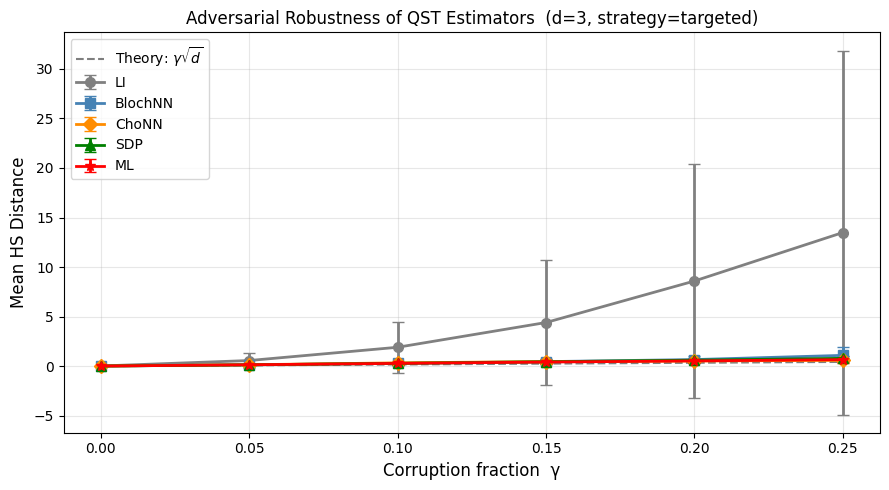


Comparing strategies at γ=0.1...


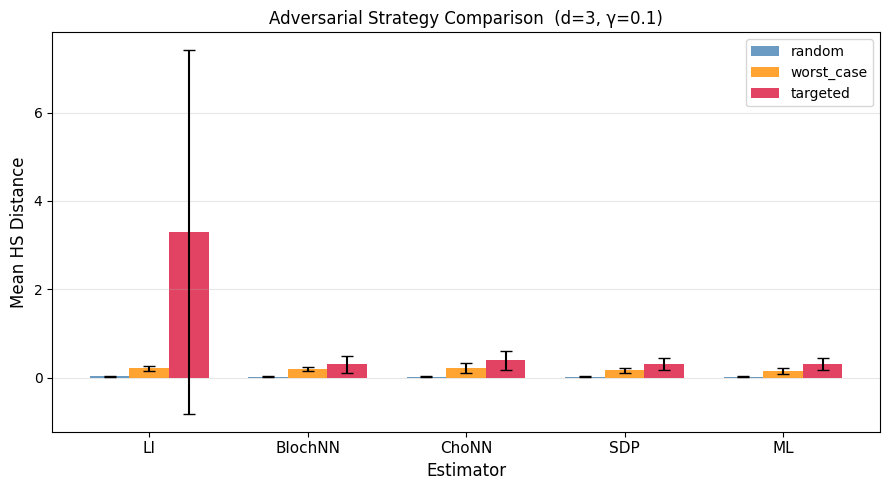

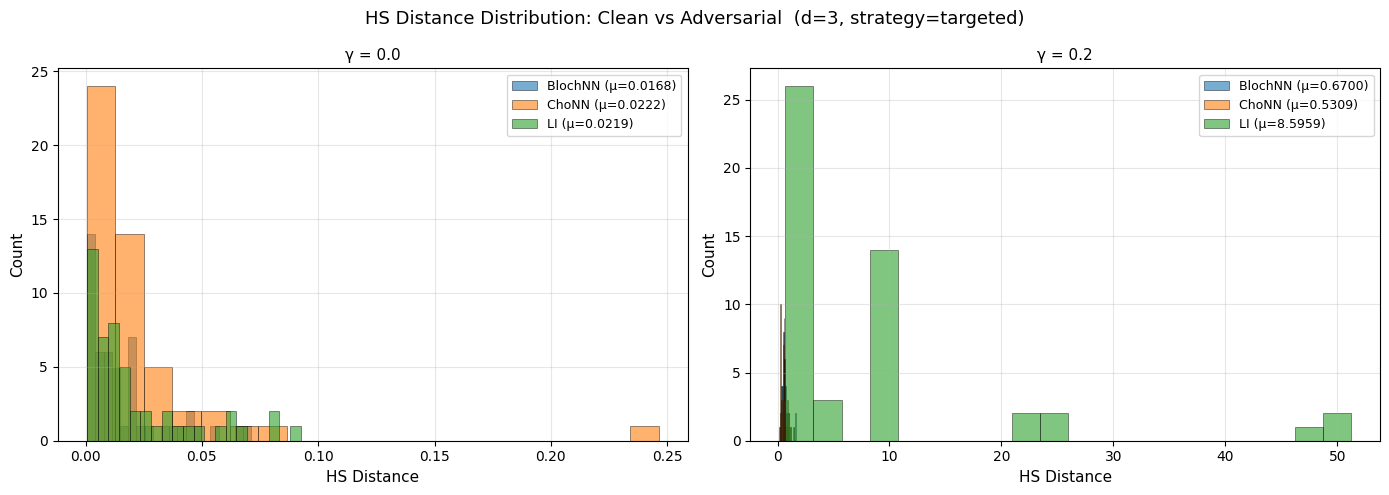

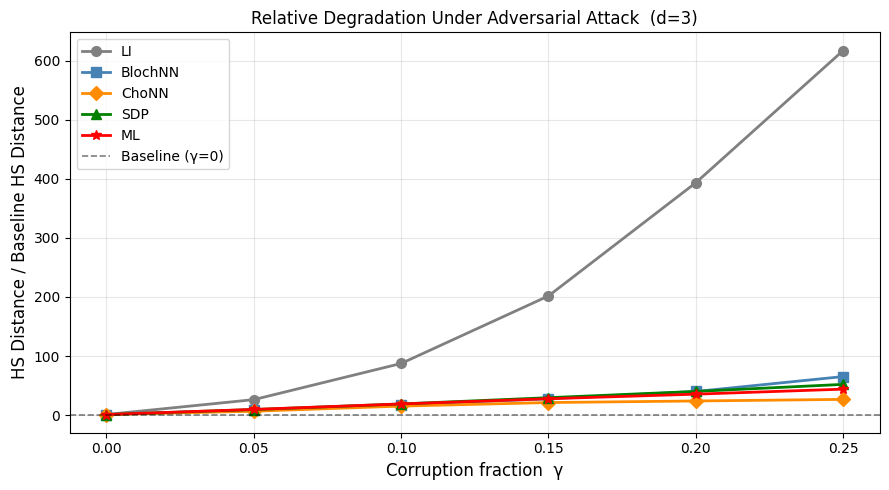

In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# ADVERSARIAL ATTACK EVALUATION
# Matches the structure of your existing code exactly
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt

# ── Adversarial corruption functions ─────────────────────────────────────────

def freq_to_outcomes(freq_vec, n_trials=10000):
    """Convert frequency vector to discrete outcomes via multinomial sampling."""
    p = array(freq_vec, dtype=float64)
    p = clip(p, 0, None)
    p /= p.sum()
    outcomes = random.choice(len(p), size=n_trials, p=p)
    return outcomes

def corrupt_outcomes(outcomes, gamma, n_povm_outcomes, strategy='targeted'):
    """
    Corrupt exactly floor(gamma * n) outcomes.
    Matches Definition 1.2 of Aliakbarpour et al. (2025).
    """
    n         = len(outcomes)
    corrupted = outcomes.copy()
    n_corrupt = int(floor(gamma * n))      # hard constraint, not probabilistic
    if n_corrupt == 0:
        return corrupted

    corrupt_indices = random.choice(n, size=n_corrupt, replace=False)

    if strategy == 'random':
        # Weakest: random replacement
        corrupted[corrupt_indices] = random.randint(0, n_povm_outcomes,
                                                    size=n_corrupt)
    elif strategy == 'worst_case':
        # Moderate: always inject outcome 0
        corrupted[corrupt_indices] = 0

    elif strategy == 'targeted':
        # Strongest: inject the least probable outcome
        least_likely = argmin(bincount(outcomes, minlength=n_povm_outcomes))
        corrupted[corrupt_indices] = least_likely

    return corrupted

def outcomes_to_freq(outcomes, n_povm_outcomes):
    """Convert discrete outcomes back to a normalised frequency vector."""
    counts = bincount(outcomes, minlength=n_povm_outcomes)
    return (counts / len(outcomes)).astype(float32)

def corrupt_freq_vector(freq_vec, gamma, n_povm_outcomes,
                        strategy='targeted', n_trials=10000):
    """Full pipeline: freq → outcomes → corrupt → freq."""
    outcomes           = freq_to_outcomes(freq_vec, n_trials)
    corrupted_outcomes = corrupt_outcomes(outcomes, gamma,
                                          n_povm_outcomes, strategy)
    return outcomes_to_freq(corrupted_outcomes, n_povm_outcomes)


# ── Single state evaluation under adversarial attack ─────────────────────────

def evaluate_single_state_adversarial(rho_true, probsTrue, gamma,
                                       strategy='targeted', n_trials=10000):
    """
    Given a true state and its true probability distribution,
    corrupt the frequency vector and evaluate all estimators.
    Returns a dict of HS distances.
    """
    # Step 1: corrupt the probability vector
    probD_corr = corrupt_freq_vector(probsTrue, gamma, dim**2,
                                     strategy=strategy,
                                     n_trials=n_trials)

    # Step 2: Linear Inversion
    blochLI_corr = dot(la.pinv(cmat), probD_corr.transpose())
    rhoLI_corr   = rhoFromBlochG(blochLI_corr, GAll)

    # Step 3: Bloch NN
    x_corr        = reshape(probD_corr, (1, dim**2))
    blochPred_corr = modelBloch.predict(x=x_corr, verbose=0) * sqrt(dim - 1)
    rhoB_corr     = rhoFromBlochG(blochPred_corr[0], GAll)

    # Step 4: Cholesky NN
    choPred_corr = modelCho.predict(x=x_corr, verbose=0)
    rhoC_corr    = rhoFromCho(choPred_corr[0])

    # Step 5: SDP
    import cvxpy as cp
    x_sdp         = cp.Variable(dim**2)
    constraints   = [rhoFromBlochG(x_sdp, GAll) >> 0]
    constraints  += [cp.trace(rhoFromBlochG(x_sdp, GAll)) == 1]
    prob_sdp      = cp.Problem(
                        cp.Minimize(cp.sum_squares((cmat @ x_sdp) - probD_corr)),
                        constraints)
    prob_sdp.solve(verbose=False)
    rhoSDP_corr   = rhoFromBlochG(prob_sdp.variables()[0].value, GAll)

    # Step 6: Maximum Likelihood
    rhoML_corr = MLalg(probD_corr, identity(dim) / dim,
                       pom, 10**(-14), 10**5)

    return {
        'LI':      real(HSdist(rho_true, rhoLI_corr)),
        'BlochNN': real(HSdist(rho_true, rhoB_corr)),
        'ChoNN':   real(HSdist(rho_true, rhoC_corr)),
        'SDP':     real(HSdist(rho_true, rhoSDP_corr)),
        'ML':      real(HSdist(rho_true, rhoML_corr)),
    }


# ── Sweep over gamma values ───────────────────────────────────────────────────

n_states  = 50                                    # number of random test states
n_trials  = 10000                                 # single-copy measurements
gammas    = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]  # corruption fractions
strategy  = 'targeted'                            # strongest adversary

# Storage: results[gamma][method] = list of HS distances
results = {g: {'LI': [], 'BlochNN': [], 'ChoNN': [], 'SDP': [], 'ML': []}
           for g in gammas}

print(f"Evaluating {n_states} states across {len(gammas)} gamma values...")
print(f"Strategy: {strategy},  n_trials: {n_trials},  dim: {dim}")
print("─" * 60)

for state_idx in range(n_states):
    if state_idx % 10 == 0:
        print(f"  State {state_idx}/{n_states}...")

    # Generate a fresh random state
    rho_true  = randomHS(dim)
    probsTrue = probdists(rho_true, pom)

    for gamma in gammas:
        if gamma == 0.0:
            # Clean case: use sampled (not corrupted) frequencies
            probD_clean = random.multinomial(n_trials, probsTrue) / n_trials
            x_clean     = reshape(probD_clean, (1, dim**2))

            blochLI  = dot(la.pinv(cmat), probD_clean)
            rhoLI    = rhoFromBlochG(blochLI, GAll)

            blochP   = modelBloch.predict(x=x_clean, verbose=0) * sqrt(dim - 1)
            rhoB     = rhoFromBlochG(blochP[0], GAll)

            choP     = modelCho.predict(x=x_clean, verbose=0)
            rhoC     = rhoFromCho(choP[0])

            import cvxpy as cp
            x_sdp       = cp.Variable(dim**2)
            constr      = [rhoFromBlochG(x_sdp, GAll) >> 0,
                           cp.trace(rhoFromBlochG(x_sdp, GAll)) == 1]
            cp.Problem(cp.Minimize(
                cp.sum_squares((cmat @ x_sdp) - probD_clean)),
                constr).solve(verbose=False)
            rhoSDP = rhoFromBlochG(cp.Problem.variables(
                cp.Problem(cp.Minimize(
                    cp.sum_squares((cmat @ x_sdp) - probD_clean)),
                    constr))[0].value, GAll)

            rhoML = MLalg(probD_clean, identity(dim) / dim,
                          pom, 10**(-14), 10**5)

            distances = {
                'LI':      real(HSdist(rho_true, rhoLI)),
                'BlochNN': real(HSdist(rho_true, rhoB)),
                'ChoNN':   real(HSdist(rho_true, rhoC)),
                'SDP':     real(HSdist(rho_true, rhoSDP)),
                'ML':      real(HSdist(rho_true, rhoML)),
            }
        else:
            distances = evaluate_single_state_adversarial(
                rho_true, probsTrue, gamma, strategy, n_trials)

        for method, dist in distances.items():
            results[gamma][method].append(dist)

print("Done.")


# ── Compute means and standard deviations ────────────────────────────────────

methods    = ['LI', 'BlochNN', 'ChoNN', 'SDP', 'ML']
means      = {m: [] for m in methods}
stds       = {m: [] for m in methods}

for gamma in gammas:
    for method in methods:
        vals = array(results[gamma][method])
        means[method].append(vals.mean())
        stds[method].append(vals.std())

# Print summary table
print(f"\n{'γ':>6}  {'LI':>10}  {'BlochNN':>10}  "
      f"{'ChoNN':>10}  {'SDP':>10}  {'ML':>10}")
print("─" * 62)
for i, gamma in enumerate(gammas):
    row = f"{gamma:>6.2f}"
    for method in methods:
        row += f"  {means[method][i]:>10.5f}"
    print(row)


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – HS distance vs gamma for all estimators
# ═══════════════════════════════════════════════════════════════════════════════

colors  = {'LI': 'grey', 'BlochNN': 'steelblue',
           'ChoNN': 'darkorange', 'SDP': 'green', 'ML': 'red'}
markers = {'LI': 'o', 'BlochNN': 's', 'ChoNN': 'D', 'SDP': '^', 'ML': '*'}

fig, ax = plt.subplots(figsize=(9, 5))

for method in methods:
    ax.errorbar(gammas,
                means[method],
                yerr=stds[method],
                label=method,
                color=colors[method],
                marker=markers[method],
                linewidth=2,
                markersize=7,
                capsize=4)

# Theoretical scaling γ√d (from Theorem 1.4 of the paper)
gamma_theory = array(gammas)
theory_scale = gamma_theory * sqrt(dim)
ax.plot(gammas, theory_scale,
        'k--', linewidth=1.5, alpha=0.5,
        label=r'Theory: $\gamma\sqrt{d}$')

ax.set_xlabel('Corruption fraction  γ', fontsize=12)
ax.set_ylabel('Mean HS Distance', fontsize=12)
ax.set_title(f'Adversarial Robustness of QST Estimators  '
             f'(d={dim}, strategy={strategy})', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_adversarial_vs_gamma.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Strategy comparison for NN estimators at fixed gamma
# ═══════════════════════════════════════════════════════════════════════════════

gamma_fixed  = 0.10
strategies   = ['random', 'worst_case', 'targeted']
nn_methods   = ['BlochNN', 'ChoNN']

strat_results = {s: {m: [] for m in methods} for s in strategies}

print(f"\nComparing strategies at γ={gamma_fixed}...")

for state_idx in range(n_states):
    rho_true  = randomHS(dim)
    probsTrue = probdists(rho_true, pom)

    for strat in strategies:
        d_strat = evaluate_single_state_adversarial(
            rho_true, probsTrue, gamma_fixed, strat, n_trials)
        for method, dist in d_strat.items():
            strat_results[strat][method].append(dist)

fig, ax = plt.subplots(figsize=(9, 5))

x_pos    = arange(len(methods))
width    = 0.25
strat_colors = {'random': 'steelblue',
                'worst_case': 'darkorange',
                'targeted': 'crimson'}

for k, strat in enumerate(strategies):
    bar_means = [array(strat_results[strat][m]).mean() for m in methods]
    bar_stds  = [array(strat_results[strat][m]).std()  for m in methods]
    ax.bar(x_pos + k * width,
           bar_means,
           width,
           yerr=bar_stds,
           label=strat,
           color=strat_colors[strat],
           alpha=0.8,
           capsize=4)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(methods, fontsize=11)
ax.set_xlabel('Estimator', fontsize=12)
ax.set_ylabel('Mean HS Distance', fontsize=12)
ax.set_title(f'Adversarial Strategy Comparison  '
             f'(d={dim}, γ={gamma_fixed})', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 – HS distance distribution at gamma=0 vs gamma=0.2
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HS Distance Distribution: Clean vs Adversarial  '
             f'(d={dim}, strategy={strategy})', fontsize=13)

for ax, gamma_plot in zip(axes, [0.0, 0.20]):
    for method in ['BlochNN', 'ChoNN', 'LI']:
        vals = array(results[gamma_plot][method])
        ax.hist(vals, bins=20, alpha=0.6,
                label=f'{method} (μ={vals.mean():.4f})',
                edgecolor='black', linewidth=0.5)
    ax.set_xlabel('HS Distance', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'γ = {gamma_plot}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_distribution_clean_vs_adversarial.png',
            dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 – Relative degradation: how much worse under attack
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 5))

for method in methods:
    baseline    = means[method][0]              # gamma = 0
    degradation = [m / baseline for m in means[method]]
    ax.plot(gammas, degradation,
            label=method,
            color=colors[method],
            marker=markers[method],
            linewidth=2,
            markersize=7)

ax.axhline(1.0, color='black', linestyle='--',
           linewidth=1.2, alpha=0.5, label='Baseline (γ=0)')
ax.set_xlabel('Corruption fraction  γ', fontsize=12)
ax.set_ylabel('HS Distance / Baseline HS Distance', fontsize=12)
ax.set_title(f'Relative Degradation Under Adversarial Attack  '
             f'(d={dim})', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_relative_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

Evaluating 50 states | strategy=targeted | dim=3
───────────────────────────────────────────────────────
  State 0/50...
  State 10/50...
  State 20/50...
  State 30/50...
  State 40/50...
Done.

     γ     BlochNN       ChoNN         SDP          ML
──────────────────────────────────────────────────
  0.00     0.01685     0.01722     0.01621     0.01598
  0.05     0.12402     0.16463     0.11851     0.12080
  0.10     0.28646     0.36022     0.25515     0.25083
  0.15     0.47507     0.51553     0.44657     0.40404
  0.20     0.73145     0.60008     0.65474     0.56419
  0.25     1.02304     0.67327     0.82779     0.70170


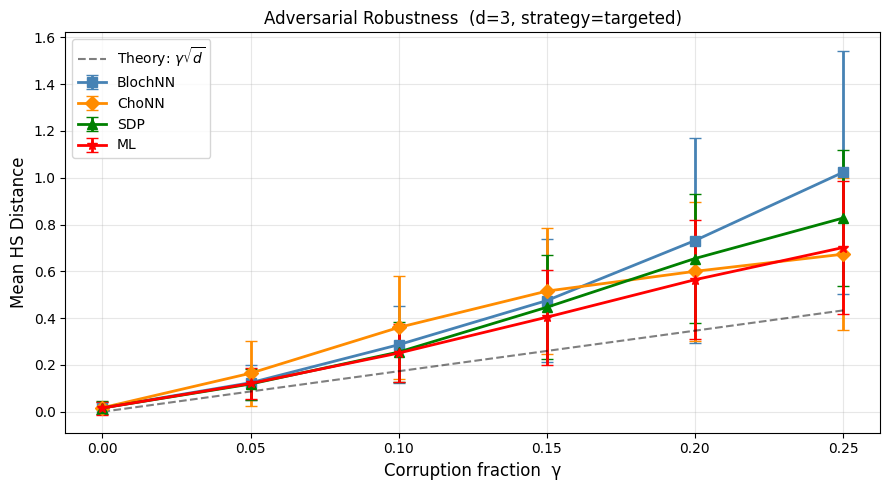


Strategy comparison at γ=0.1...


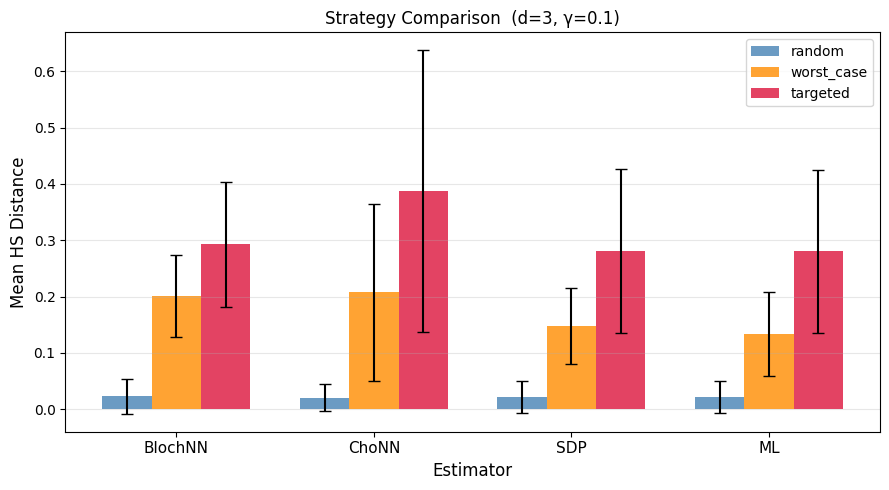

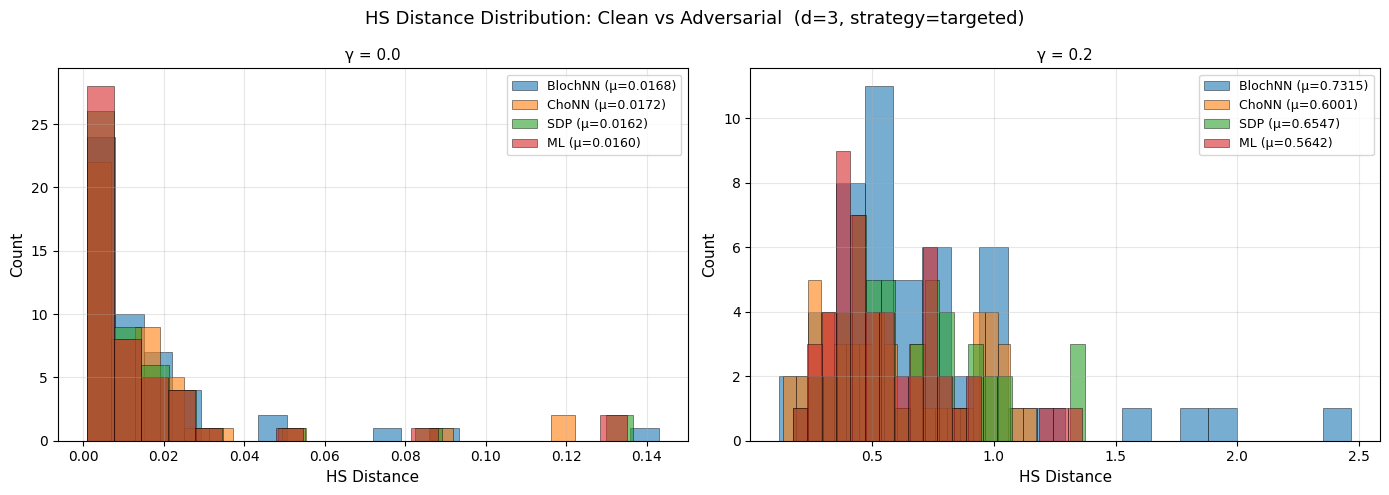

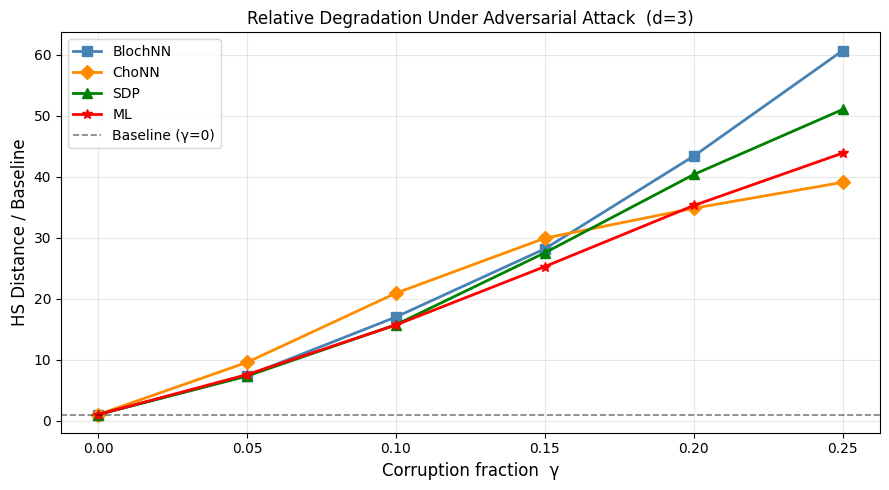

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# ADVERSARIAL ATTACK EVALUATION (without Linear Inversion)
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

# ── Adversarial corruption functions ─────────────────────────────────────────

def freq_to_outcomes(freq_vec, n_trials=10000):
    p = array(freq_vec, dtype=float64)
    p = clip(p, 0, None)
    p /= p.sum()
    return random.choice(len(p), size=n_trials, p=p)

def corrupt_outcomes(outcomes, gamma, n_povm_outcomes, strategy='targeted'):
    n         = len(outcomes)
    corrupted = outcomes.copy()
    n_corrupt = int(floor(gamma * n))
    if n_corrupt == 0:
        return corrupted
    corrupt_indices = random.choice(n, size=n_corrupt, replace=False)
    if strategy == 'random':
        corrupted[corrupt_indices] = random.randint(0, n_povm_outcomes,
                                                    size=n_corrupt)
    elif strategy == 'worst_case':
        corrupted[corrupt_indices] = 0
    elif strategy == 'targeted':
        least_likely = argmin(bincount(outcomes, minlength=n_povm_outcomes))
        corrupted[corrupt_indices] = least_likely
    return corrupted

def outcomes_to_freq(outcomes, n_povm_outcomes):
    counts = bincount(outcomes, minlength=n_povm_outcomes)
    return (counts / len(outcomes)).astype(float32)

def corrupt_freq_vector(freq_vec, gamma, n_povm_outcomes,
                        strategy='targeted', n_trials=10000):
    outcomes           = freq_to_outcomes(freq_vec, n_trials)
    corrupted_outcomes = corrupt_outcomes(outcomes, gamma,
                                          n_povm_outcomes, strategy)
    return outcomes_to_freq(corrupted_outcomes, n_povm_outcomes)


# ── Single state evaluation ───────────────────────────────────────────────────

def evaluate_single_state(probD, rho_true):
    """Evaluate all estimators (no LI) on a given probability vector."""
    x_in = reshape(probD, (1, dim**2))

    # Bloch NN
    blochP = modelBloch.predict(x=x_in, verbose=0) * sqrt(dim - 1)
    rhoB   = rhoFromBlochG(blochP[0], GAll)

    # Cholesky NN
    choP = modelCho.predict(x=x_in, verbose=0)
    rhoC = rhoFromCho(choP[0])

    # SDP
    x_sdp      = cp.Variable(dim**2)
    constr     = [rhoFromBlochG(x_sdp, GAll) >> 0,
                  cp.trace(rhoFromBlochG(x_sdp, GAll)) == 1]
    cp.Problem(cp.Minimize(
        cp.sum_squares((cmat @ x_sdp) - probD)),
        constr).solve(verbose=False)
    rhoSDP = rhoFromBlochG(x_sdp.value, GAll)

    # ML
    rhoML = MLalg(probD, identity(dim) / dim, pom, 10**(-14), 10**5)

    return {
        'BlochNN': real(HSdist(rho_true, rhoB)),
        'ChoNN':   real(HSdist(rho_true, rhoC)),
        'SDP':     real(HSdist(rho_true, rhoSDP)),
        'ML':      real(HSdist(rho_true, rhoML)),
    }


def evaluate_adversarial(rho_true, probsTrue, gamma,
                         strategy='targeted', n_trials=10000):
    """Corrupt frequency vector then evaluate all estimators."""
    probD_corr = corrupt_freq_vector(probsTrue, gamma, dim**2,
                                     strategy=strategy,
                                     n_trials=n_trials)
    return evaluate_single_state(probD_corr, rho_true)


# ── Sweep over gamma values ───────────────────────────────────────────────────

n_states = 50
n_trials = 10000
gammas   = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
strategy = 'targeted'
methods  = ['BlochNN', 'ChoNN', 'SDP', 'ML']

results  = {g: {m: [] for m in methods} for g in gammas}

print(f"Evaluating {n_states} states | strategy={strategy} | dim={dim}")
print("─" * 55)

for state_idx in range(n_states):
    if state_idx % 10 == 0:
        print(f"  State {state_idx}/{n_states}...")

    rho_true  = randomHS(dim)
    probsTrue = probdists(rho_true, pom)

    for gamma in gammas:
        if gamma == 0.0:
            # clean sampled frequencies
            probD = random.multinomial(n_trials, probsTrue) / n_trials
        else:
            probD = corrupt_freq_vector(probsTrue, gamma, dim**2,
                                        strategy=strategy,
                                        n_trials=n_trials)
        dists = evaluate_single_state(probD, rho_true)
        for m, v in dists.items():
            results[gamma][m].append(v)

print("Done.")

# ── Summary table ─────────────────────────────────────────────────────────────

means = {m: [] for m in methods}
stds  = {m: [] for m in methods}

for gamma in gammas:
    for m in methods:
        vals = array(results[gamma][m])
        means[m].append(vals.mean())
        stds[m].append(vals.std())

print(f"\n{'γ':>6}  {'BlochNN':>10}  {'ChoNN':>10}  "
      f"{'SDP':>10}  {'ML':>10}")
print("─" * 50)
for i, gamma in enumerate(gammas):
    row = f"{gamma:>6.2f}"
    for m in methods:
        row += f"  {means[m][i]:>10.5f}"
    print(row)


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 – HS distance vs gamma
# ═══════════════════════════════════════════════════════════════════════════════

colors  = {'BlochNN': 'steelblue', 'ChoNN': 'darkorange',
           'SDP': 'green',         'ML': 'red'}
markers = {'BlochNN': 's', 'ChoNN': 'D', 'SDP': '^', 'ML': '*'}

fig, ax = plt.subplots(figsize=(9, 5))

for m in methods:
    ax.errorbar(gammas, means[m], yerr=stds[m],
                label=m, color=colors[m], marker=markers[m],
                linewidth=2, markersize=7, capsize=4)

# Theoretical γ√d scaling (Theorem 1.4)
g_arr        = array(gammas)
theory_scale = g_arr * sqrt(dim)
ax.plot(gammas, theory_scale, 'k--', linewidth=1.5,
        alpha=0.5, label=r'Theory: $\gamma\sqrt{d}$')

ax.set_xlabel('Corruption fraction  γ', fontsize=12)
ax.set_ylabel('Mean HS Distance', fontsize=12)
ax.set_title(f'Adversarial Robustness  (d={dim}, strategy={strategy})',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_hs_vs_gamma.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 – Strategy comparison at fixed gamma
# ═══════════════════════════════════════════════════════════════════════════════

gamma_fixed  = 0.10
strategies   = ['random', 'worst_case', 'targeted']
strat_colors = {'random': 'steelblue',
                'worst_case': 'darkorange',
                'targeted': 'crimson'}

strat_results = {s: {m: [] for m in methods} for s in strategies}

print(f"\nStrategy comparison at γ={gamma_fixed}...")

for _ in range(n_states):
    rho_true  = randomHS(dim)
    probsTrue = probdists(rho_true, pom)
    for strat in strategies:
        dists = evaluate_adversarial(rho_true, probsTrue,
                                     gamma_fixed, strat, n_trials)
        for m, v in dists.items():
            strat_results[strat][m].append(v)

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = arange(len(methods))
width = 0.25

for k, strat in enumerate(strategies):
    bar_means = [array(strat_results[strat][m]).mean() for m in methods]
    bar_stds  = [array(strat_results[strat][m]).std()  for m in methods]
    ax.bar(x_pos + k * width, bar_means, width,
           yerr=bar_stds, label=strat,
           color=strat_colors[strat], alpha=0.8, capsize=4)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(methods, fontsize=11)
ax.set_xlabel('Estimator', fontsize=12)
ax.set_ylabel('Mean HS Distance', fontsize=12)
ax.set_title(f'Strategy Comparison  (d={dim}, γ={gamma_fixed})',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig2_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 – Distribution: clean vs adversarial
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'HS Distance Distribution: Clean vs Adversarial  '
             f'(d={dim}, strategy={strategy})', fontsize=13)

for ax, g_plot in zip(axes, [0.0, 0.20]):
    for m in methods:
        vals = array(results[g_plot][m])
        ax.hist(vals, bins=20, alpha=0.6,
                label=f'{m} (μ={vals.mean():.4f})',
                edgecolor='black', linewidth=0.5)
    ax.set_xlabel('HS Distance', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'γ = {g_plot}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 – Relative degradation
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 5))

for m in methods:
    baseline    = means[m][0]
    degradation = [v / baseline for v in means[m]]
    ax.plot(gammas, degradation,
            label=m, color=colors[m],
            marker=markers[m], linewidth=2, markersize=7)

ax.axhline(1.0, color='black', linestyle='--',
           linewidth=1.2, alpha=0.5, label='Baseline (γ=0)')
ax.set_xlabel('Corruption fraction  γ', fontsize=12)
ax.set_ylabel('HS Distance / Baseline', fontsize=12)
ax.set_title(f'Relative Degradation Under Adversarial Attack  '
             f'(d={dim})', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_relative_degradation.png', dpi=150, bbox_inches='tight')
plt.show()